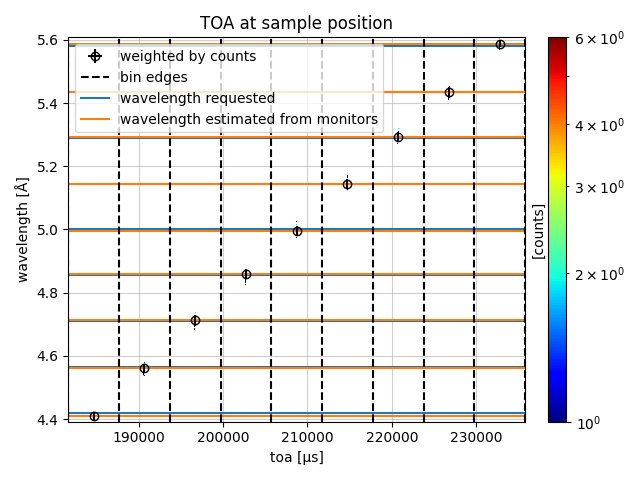

In [17]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
from trex.instrument import Instrument


central_wavelength = 5 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 12
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
wavelength_requested = trex.calculate_incoming_wavelength()
res = trex.model.run()
wavelength_estimated = trex.estimate_incoming_wavelength(model_result=res)


fig, ax = plt.subplots()

for wa in wavelength_requested:
    hline_ei = ax.axhline(
        y=wa.values, c="C0", linestyle="-", label="wavelength requested"
    )
for wa in wavelength_estimated:
    hline_ei_est = ax.axhline(
        y=wa.values, c="C1", linestyle="-", label="wavelength estimated from monitors"
    )

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Monitor at Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]
# Histogram and plot
toa_sample = events_at_sample.hist(wavelength=800, toa=1000).plot(
    norm="log", cbar=True, ax=ax, cmap="jet", title="TOA at sample position"
)

toa_bin_edges = trex.monitors["Monitor at Sample"].calculate_toa_bin_edges()
toa_binned = events_at_sample.bin(toa=toa_bin_edges)

for edge in toa_bin_edges:
    vline_edges = ax.axvline(x=edge.values, c="k", linestyle="--", label="bin edges")


# Weighted mean of wavelength inside each bin
wavelength_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["wavelength"]
).bins.sum() / toa_binned.bins.sum()

# Variance of wavelengths inside each bin
wavelength_var = (
    toa_binned.bins.data * (toa_binned.bins.coords["wavelength"] - wavelength_mu) ** 2
) / toa_binned.bins.sum()

# Weighted mean of TOA inside each bin
toa_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["toa"]
).bins.sum() / toa_binned.bins.sum()

# Variance of TOA inside each bin
toa_var = (
    toa_binned.bins.data * (toa_binned.bins.coords["toa"] - toa_mu) ** 2
) / toa_binned.bins.sum()

ebplot = ax.errorbar(
    x=toa_mu.values,
    xerr=sc.sqrt(toa_var.hist()).values,
    y=wavelength_mu.values,
    yerr=sc.sqrt(wavelength_var.hist()).values,
    fmt="ok",
    linestyle="",
    mfc="none",
    label="weighted by counts",
)
ax.grid(alpha=0.6)
ax.set_xlim((toa_bin_edges.min().values, toa_bin_edges.max().values))
ax.legend(handles=[ebplot, vline_edges, hline_ei, hline_ei_est], loc=0)
fig.tight_layout()
plt.show()

In [18]:
print(trex.source)


Source:
  pulses=1, neutrons per pulse=1000000
  frequency=14.0 Hz
  facility='ess'
  distance=0.0 m
  time range=(12.800, 4381.728) [µs]
  wavelength range=(0.199, 6.521) [Å]


In [19]:
import plopp as pp

toa_m3_edges = trex.monitors["Monitor 3"].calculate_toa_bin_edges()
toa_det_edges = trex.monitors["Beamstop Monitor"].calculate_toa_bin_edges()


toa_bin_to_plot = sc.linspace(
    "toa", toa_m3_edges.min(), toa_det_edges.max(), num=500 * (len(toa_m3_edges) - 1)
)
hist_m3 = res.detectors["Monitor 3"].data.hist(toa=toa_bin_to_plot)
hist_det = res.detectors["Beamstop Monitor"].data.hist(toa=toa_bin_to_plot)

pp.plot({"Monitor 3": hist_m3, "Beamstop Monitor": hist_det}, grid=True)  # type: ignore

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [20]:
res = trex.model.run()
toa_centers_m3 = trex.monitors["Monitor 3"].estimate_toa_centroid(model_result=res)
toa_centers_bs = trex.monitors["Beamstop Monitor"].estimate_toa_centroid(
    model_result=res
)

print(toa_centers_m3.data)
print(toa_centers_bs.data)

<scipp.Variable> (toa: 9)    float64            [µs]  [183980, 189974, ..., 225955, 231959]
<scipp.Variable> (toa: 9)    float64            [µs]  [187992, 194124, ..., 230900, 237044]


In [21]:
wavelength = trex.estimate_incoming_wavelength(res)
wavelength_requested = trex.calculate_incoming_wavelength()

print(wavelength)
print(wavelength_requested)
print(wavelength_requested.values)

<scipp.Variable> (wavelength: 9)    float64             [Å]  [4.40938, 4.56039, ..., 5.43421, 5.58839]
<scipp.Variable> (wavelength: 9)    float64             [Å]  [4.41857, 4.56393, ..., 5.43607, 5.58143]
[4.41857231 4.56392923 4.70928615 4.85464308 5.         5.14535692
 5.29071385 5.43607077 5.58142769]


In [22]:
ei = trex.estimate_incoming_energy(res)
ei_requested = trex.calculate_incoming_energy()

print(ei)
print(ei_requested)
print(ei.values)

<scipp.Variable> (energy: 9)    float64            [meV]  [4.20746, 3.93344, ..., 2.77015, 2.6194]
<scipp.Variable> (energy: 9)    float64            [meV]  [4.18998, 3.92733, ..., 2.76825, 2.62594]
[4.20745888 3.9334365  3.68343429 3.46697068 3.27778481 3.09218281
 2.92116477 2.7701478  2.61940314]


In [23]:
trex.wrap_frame(res)

hist_m3 = res["Monitor 3"].data.hist(toa=5000)
hist_det = res["Beamstop Monitor"].data.hist(toa=5000)

pp.plot({"Monitor 3": hist_m3, "Beamstop Monitor": hist_det}, grid=True)  # type: ignore

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [24]:
trex.unwrap_frame(res)

hist_m3 = res["Monitor 3"].data.hist(toa=5000)
hist_det = res["Beamstop Monitor"].data.hist(toa=5000)

pp.plot({"Monitor 3": hist_m3, "Beamstop Monitor": hist_det}, grid=True)  # type: ignore

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [27]:
wavelength = trex.estimate_incoming_wavelength(res)
print(wavelength)

<scipp.Variable> (wavelength: 9)    float64             [Å]  [4.40938, 4.56039, ..., 5.43421, 5.58839]
